In [1]:
import pickle as pkl
import pandas as pd

final_df= pd.read_pickle('final_df3.pkl')
print(final_df)

print(final_df['Period'])

     Year  Temp_DJF  Precip_DJF  Temp_MJJAS  Precip_MJJAS  GlacierId  \
0    1951 -4.362798    6.185266    9.747061     10.721021     2636.0   
1    1952 -2.419369    8.807426    9.220020     12.433246     2636.0   
2    1953 -5.094279    7.743274   10.786901     11.524487     2636.0   
3    1954 -3.825318    5.963656   10.494399     12.956203     2636.0   
4    1955 -4.074505    7.468448    9.956315      9.585814     2636.0   
..    ...       ...         ...         ...           ...        ...   
545  2022 -2.855950    9.078746   11.289492     13.741344     2768.0   
546  2022 -2.855950    9.078746   11.289492     13.741344       54.0   
547  2022 -2.855950    9.078746   11.289492     13.741344     2297.0   
548  2022 -2.855950    9.078746   11.289492     13.741344     2968.0   
549  2022 -2.855950    9.078746   11.289492     13.741344     2636.0   

              Glacier    Bs    Bw    Ba  ...    SSRD_DJF  SSRD_MJJAS  \
0           Storbreen -1.67  1.13 -0.54  ...  2980521.00  75456

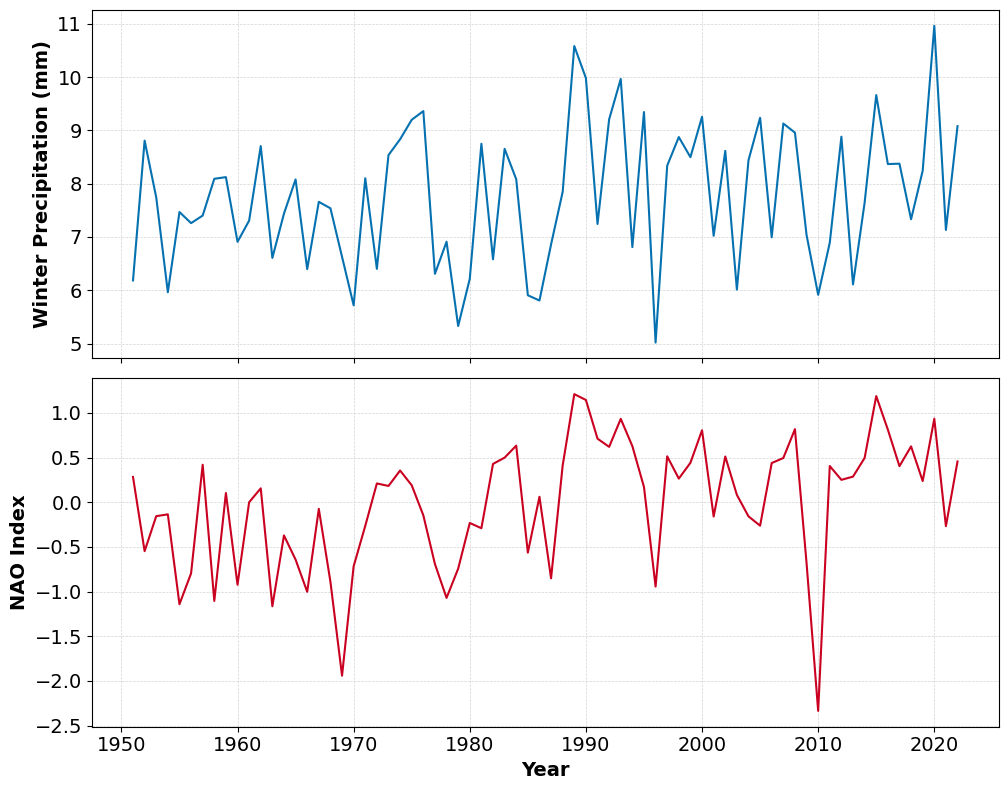

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax= plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)
gridline_color = "#d3d3d3"

ax[0].plot(final_df['Year'], final_df['Precip_DJF'], color='#0571b0', linewidth=1.5)
ax[0].set_ylabel('Winter Precipitation (mm)', size=14, fontweight='bold')
ax[0].tick_params(axis='y', labelsize=14)
ax[0].grid(color=gridline_color, linestyle='--', linewidth=0.5)

ax[1].plot(final_df['Year'], final_df['PC1_DJF'], color='#ca0020', linewidth=1.5)
ax[1].set_ylabel('NAO Index', size=14, fontweight='bold')
ax[1].set_xlabel('Year', size=14, fontweight='bold')
ax[1].tick_params(axis='y', labelsize=14)
ax[1].tick_params(axis='x', labelsize=14)
ax[1].grid(color=gridline_color, linestyle='--', linewidth=0.5)

plt.tight_layout()
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\winter_precip_nao_index.png', dpi=800, bbox_inches='tight')
plt.show()


In [3]:
from scipy.stats import pearsonr, spearmanr

r_p, p_p= pearsonr(final_df['PC1_DJF'], final_df['Precip_DJF'])
r_s, p_s= spearmanr(final_df['PC1_DJF'], final_df['Precip_DJF'])

print(f"Pearson: r = {r_p:.2f}, p = {p_p:.2f}")
print(f"Spearman: r = {r_s:.2f}, p = {p_s:.2f}")

Pearson: r = 0.62, p = 0.00
Spearman: r = 0.60, p = 0.00


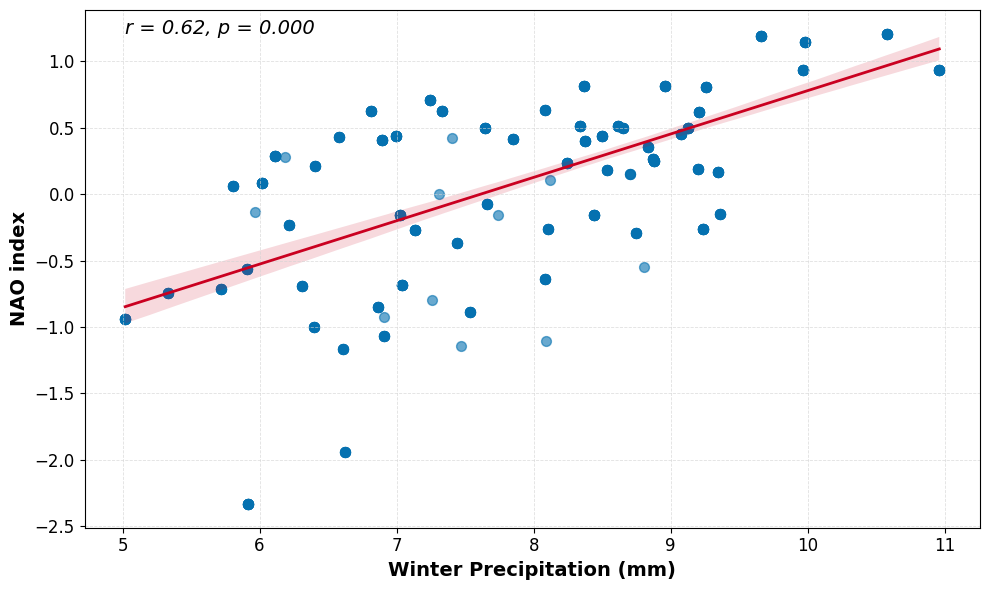

In [ ]:
# Plotting correlation NAO and Pacc

import matplotlib.pyplot as plt
import seaborn as sns

Correlation_NAO_Pacc= ['PC1_DJF', 'Precip_DJF']
cor1= final_df[Correlation_NAO_Pacc]
cor1_matrix= cor1.corr(method='pearson')

gridline_color = "#d3d3d3"

# for plotting regression line 
plt.figure(figsize=(10,6))
sns.regplot(data= final_df,
            x= 'Precip_DJF',
            y= 'PC1_DJF',
            scatter_kws={'color': '#0571b0', 'alpha': 0.6, 's': 50},
            line_kws= {'color': '#ca0020', 'linewidth': 2},
            ci= 95)

#plt.title("Correlation: PC1 vs Hurrell NAO", fontsize=14, weight='bold')
plt.ylabel("NAO index", fontsize=14, weight='bold')
plt.xlabel("Winter Precipitation (mm)", fontsize=14, weight='bold')
plt.xticks(size=12)
plt.yticks(size=12)

plt.grid(True, linestyle='--', linewidth= 0.6, color=gridline_color, alpha=0.7)

plt.text(x= final_df['Precip_DJF'].min(),
         y= final_df['PC1_DJF'].max(),
         s= f"r = {r_p:.2f}, p = {p_p:.3f}",
         fontsize=14, fontstyle='italic', color='black')

plt.tight_layout()
#plt.savefig(r'C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\correlation_plot_nao_pacc.png', dpi=800, bbox_inches='tight')
plt.show()

In [14]:
from scipy.stats import pearsonr, spearmanr

results = []

for glacier, group in final_df.groupby('GlacierShort'):
    # Pearson
    r_p_bw, p_p_bw = pearsonr(group['Ba'], group['Bw'])
    r_p_bs, p_p_bs = pearsonr(group['Ba'], group['Bs'])

    results.append({
        'GlacierShort': glacier,

        'Pearson_r_Bw': r_p_bw,
        'Pearson_p_Bw': p_p_bw,
        'Pearson_r_Bs': r_p_bs,
        'Pearson_p_Bs': p_p_bs,
    })


In [15]:
print(pd.DataFrame(results))

   GlacierShort  Pearson_r_Bw  Pearson_p_Bw  Pearson_r_Bs  Pearson_p_Bs
0           Alf      0.816958  1.728146e-15      0.746232  7.753963e-12
1           Aus      0.825614  1.035570e-09      0.854526  6.531433e-11
2           Eng      0.749891  1.032575e-10      0.719065  1.322243e-09
3          Graf      0.671685  2.267973e-03      0.607205  7.529802e-03
4          Gras      0.600342  3.151547e-07      0.935777  2.146282e-28
5           Han      0.787931  7.126831e-09      0.832557  1.669226e-10
6          Hell      0.651803  1.273489e-08      0.930033  2.475168e-27
7           Lan      0.534014  1.644166e-03      0.833494  3.189544e-09
8           Nig      0.734688  1.586867e-11      0.848782  5.683216e-18
9           Rem      0.807383  6.578204e-15      0.781612  1.706365e-13
10          Sto      0.707370  3.758116e-12      0.893377  5.051034e-26


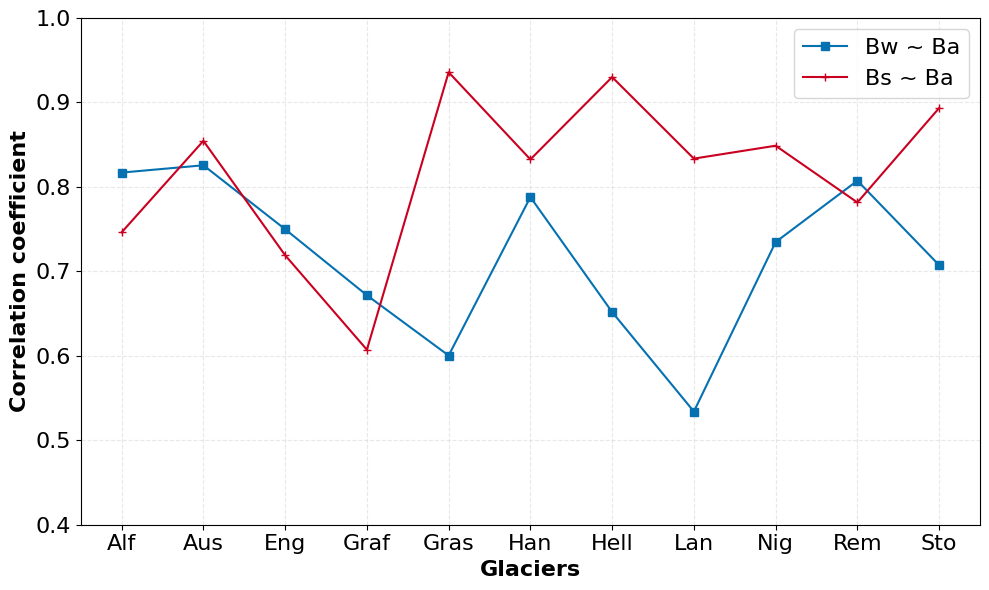

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

gridline_color = "#d3d3d3"

correlation_df = pd.DataFrame(results)

x = correlation_df['GlacierShort']
bw_corr = correlation_df['Pearson_r_Bw']
bs_corr = correlation_df['Pearson_r_Bs']

# Create plot
plt.figure(figsize=(10, 6))

# Plot both correlation lines
plt.plot(x, bw_corr, marker='s', label='Bw ~ Ba', color='#0571b0')  # square marker
plt.plot(x, bs_corr, marker='+', label='Bs ~ Ba', color= '#ca0020')  # plus marker

# Labels and limits
plt.xlabel('Glaciers', fontsize=16, fontweight='bold')
plt.ylabel('Correlation coefficient', fontsize=16, fontweight='bold')
plt.ylim(0.4, 1)
plt.xticks(x, fontsize=16) 
plt.yticks(fontsize=16)
plt.legend(fontsize=16)

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5, color=gridline_color)
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\continental-maritime_correlation.png", dpi=800, bbox_inches='tight')
plt.show()


In [17]:
from scipy.stats import pearsonr, spearmanr

results = []

for period in final_df['Period'].unique():
    group = final_df[final_df['Period'] == period]
    # Pearson
    r_p_bw, p_p_bw = pearsonr(group['PC1_DJF'], group['Bw'])
    r_p_bs, p_p_bs = pearsonr(group['PC1_DJF'], group['Bs'])

    results.append({
        'Period': period,        
        'Pearson_r_Bw': r_p_bw,
        'Pearson_p_Bw': p_p_bw,
        'Pearson_r_Bs': r_p_bs,
        'Pearson_p_Bs': p_p_bs,
    })


In [18]:
from scipy.stats import pearsonr, spearmanr

r_p, p_p= pearsonr(final_df['PC1_DJF'], final_df['Bw'])
r_s, p_s= spearmanr(final_df['PC1_DJF'], final_df['Bw'])

print(f"Pearson: r = {r_p:.2f}, p = {p_p:.2f}")
print(f"Spearman: r = {r_s:.2f}, p = {p_s:.2f}")

Pearson: r = 0.28, p = 0.00
Spearman: r = 0.28, p = 0.00


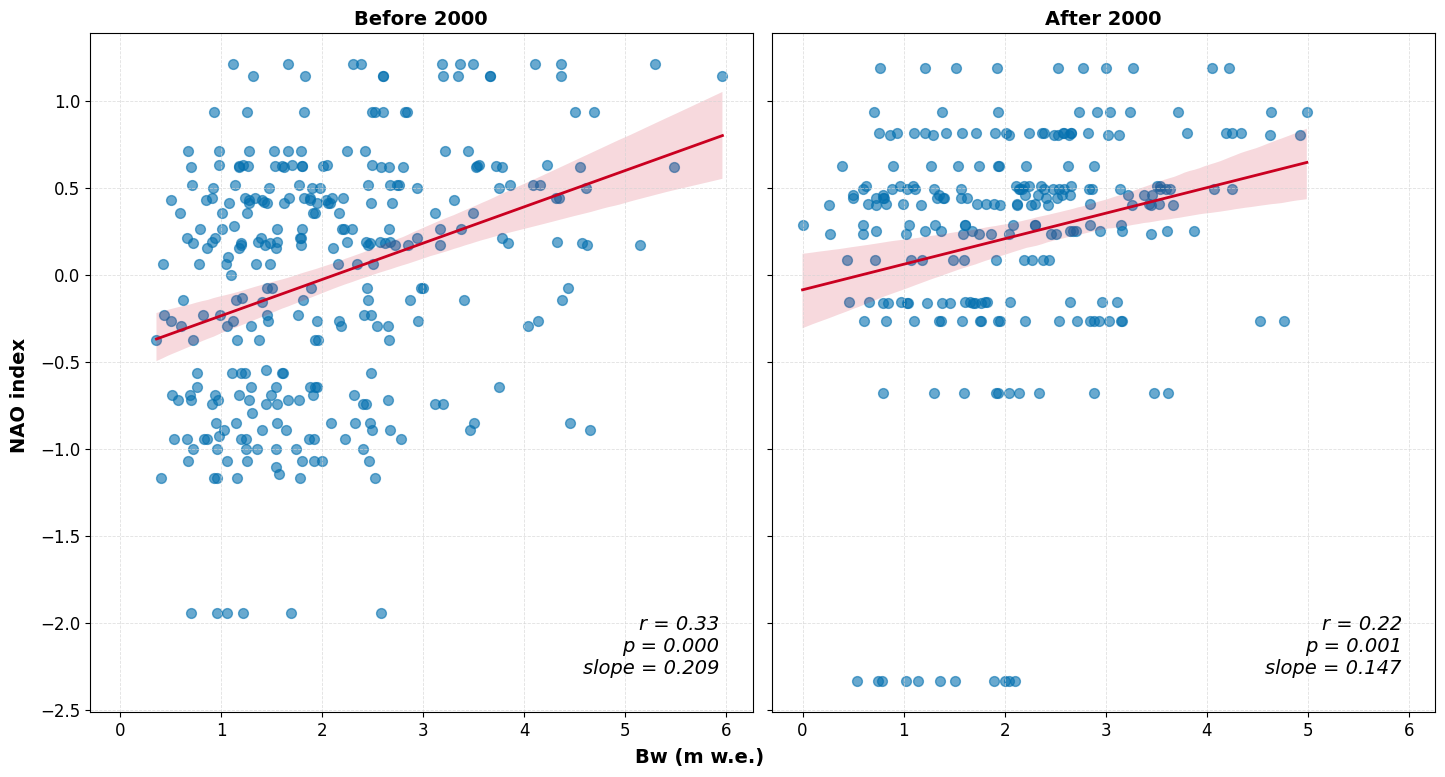

Slope change (After - Before): -0.062


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, linregress

# Split data by period
before_2000 = final_df[final_df['Period'] == 'Before_2000']
after_2000  = final_df[final_df['Period'] == 'After_2000']

gridline_color = "#d3d3d3"

# Compute correlations & slopes
slope_before, intercept_before, r_before, p_before, _ = linregress(
    before_2000['Bw'], before_2000['PC1_DJF']
)
slope_after, intercept_after, r_after, p_after, _ = linregress(
    after_2000['Bw'], after_2000['PC1_DJF']
)

# Create subplots with shared axes
fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2, figsize=(15, 8), sharex=True, sharey=True
)

# --- Before 2000 ---
sns.regplot(
    data=before_2000, x='Bw', y='PC1_DJF',
    scatter_kws={'color': '#0571b0', 'alpha': 0.6, 's': 50},
    line_kws={'color': '#ca0020', 'linewidth': 2},
    ci=95, ax=ax1
)
ax1.set_title("Before 2000", fontsize=14, weight='bold')
ax1.grid(True, linestyle='--', linewidth=0.6, color=gridline_color, alpha=0.7)
ax1.text(
    0.95, 0.05,
    f"r = {r_before:.2f}\np = {p_before:.3f}\nslope = {slope_before:.3f}",
    transform=ax1.transAxes, fontsize=14, fontstyle='italic',
    color='black', va='bottom', ha='right'
)

# --- After 2000 ---
sns.regplot(
    data=after_2000, x='Bw', y='PC1_DJF',
    scatter_kws={'color': '#0571b0', 'alpha': 0.6, 's': 50},
    line_kws={'color': '#ca0020', 'linewidth': 2},
    ci=95, ax=ax2
)
ax2.set_title("After 2000", fontsize=14, weight='bold')
ax2.grid(True, linestyle='--', linewidth=0.6, color=gridline_color, alpha=0.7)
ax2.text(
    0.95, 0.05,
    f"r = {r_after:.2f}\np = {p_after:.3f}\nslope = {slope_after:.3f}",
    transform=ax2.transAxes, fontsize=14, fontstyle='italic',
    color='black', va='bottom', ha='right'
)

# Remove subplot axis labels so only shared labels show
for ax in (ax1, ax2):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=12)

# Shared figure labels
fig.text(0.5, 0.04, "Bw (m w.e.)", ha='center', fontsize=14, weight='bold')
fig.text(0.04, 0.5, "NAO index", va='center', rotation='vertical',
         fontsize=14, weight='bold')

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\NAO_bw_periodwise_correlation.png", dpi=800, bbox_inches='tight')
plt.show()

print(f"Slope change (After - Before): {slope_after - slope_before:.3f}")
